<h1 style="text-align: center;">[Sinarmas Land]</h1>
<h3 style="text-align: center;">[Mikha, Hane, Nadya]</h3>

---

## **Section 1. Business Context**

**1.1 Context** :

**Sinarmas Land (SML) telah meredefinisi konsep pengembangan properti di Indonesia dengan bertransformasi dari sekadar pembangun perumahan menjadi perancang Kota Mandiri Terpadu (Township) berskala raksasa, seperti BSD City, Kota Wisata, dan NavaPark. Strategi ini memungkinkan SML membangun ekosistem bisnis yang berkelanjutan dan menghasilkan pendapatan berulang (recurring revenue) yang bersumber dari Iuran Pemeliharaan Lingkungan (IPL), tagihan utilitas air bersih, serta penyewaan area komersial.**
    
**Untuk mempertahankan standar fasilitas dan layanan prima setara hotel bintang lima, mulai dari keamanan 24 jam hingga pemeliharaan infrastruktur.Tim Township Management sangat bergantung pada kelancaran arus kas (cashflow) dari pembayaran IPL bulanan warga. ** 
    
**Namun, operasional raksasa ini saat ini menghadapi dua tantangan besar:**

1. Tingginya Properti Kosong (Investasi): Banyak unit properti dibeli murni untuk investasi (capital gain) dan dibiarkan kosong. Pemilik yang berdomisili di luar kota atau luar negeri sering kali mengabaikan tagihan, sehingga menciptakan tren Non-Performing Invoice (tunggakan) yang terus merangkak naik. Akibatnya, rumah tidak terawat, estetika kawasan rusak, dan SML terpaksa mensubsidi biaya operasional dari kantong perusahaan induk.  

2. Kerapian Data & Infrastruktur ERP yang Lemah: Sistem pencatatan internal (ERP) terindikasi memiliki banyak celah (bug logika) dan rentan terhadap human error. Mulai dari salah ketik angka meteran air yang memicu lonjakan tagihan tak masuk akal, ketidakseragaman pencatatan metode pembayaran, hingga data kontak konsumen yang tidak lengkap.  Analisis data secara mendalam dan pembersihan data (data cleansing) mutlak diperlukan untuk menyehatkan kembali pembukuan Estate Management serta menjaga nilai jual merek (brand value) properti SML di mata investor. 

**1.2 Problem Statements**

**Masalah Utama (Core Problem)Membengkaknya defisit operasional pada Township Management akibat tingginya akumulasi tunggakan IPL dari properti berstatus kosong (vacant), yang diperparah oleh inefisiensi sistem pencatatan tagihan utilitas serta rendahnya kualitas data pada sistem billing.**  

**Masalah Turunan (Specific Issues)**

- **Aspek Finansial & Operasional:**

- Kawasan (Township/Cluster) mana saja yang memiliki rasio tunggakan IPL tertinggi, dan seberapa besar kontribusi dari rumah berstatus kosong (vacant) terhadap total tunggakan tersebut?   

- Berapa estimasi potensi pendapatan yang hilang atau tertunda (loss/delayed revenue) akibat warga yang menunggak secara kronis (lebih dari 6 bulan berturut-turut)?  

- **Aspek Kualitas & Integritas Data (Data Quality):**
    - Seberapa besar tingkat inkonsistensi (data anomaly) pada kolom Payment Method akibat standardisasi input yang lemah?  
    - Berapa persentase data pemilik rumah yang kehilangan informasi kontak (colum Missing Values pada nomor telepon) yang menghambat efektivitas tim Collection? 

- **Aspek Bug Sistem & Logika Bisnis (System Anomalies):**
    - Ditemukan anomali fatal (logical error) di mana status tagihan telah lunas ('Paid'), namun tanggal pembayaran tercatat bertahun-tahun sebelum tanggal serah terima kunci (handover date) dilakukan.  
    - Tingginya volume data luar biasa (outliers) pada pemakaian air warga akibat kesalahan input manual lapangan yang berujung pada komplain salah tagih.  

**1.3 Key Objective**

|**Strategi**|**Deskripsi & Tujuan Operasional**|
| --- | --- |
|Revenue Recovery| Membangun dashboard aging schedule (umur piutang) untuk memfokuskan tim Collection mengejar pemilik rumah investasi yang menunggak miliaran rupiah.|
|Utility System Patching| Menambahkan fungsi validasi pada aplikasi petugas catat meteran, sehingga input pemakaian air yang melonjak >300% dari bulan sebelumnya akan otomatis diblokir untuk verifikasi ulang.|
|Data Cleansing| Menstandarisasi penamaan metode pembayaran agar tim rekonsiliasi Finance tidak perlu begadang tiap akhir bulan mencocokkan mutasi rekening bank.|
|Anti-Fraud/Bug Fix| Menutup bug logika ERP yang menerbitkan dan menerima pembayaran invoice untuk unit yang tanahnya saja bahkan belum dibangun.|




## **Section 2. Data Understanding**

# 2.1 General Information

**Skala Dataset**

Dataset terdiri dari 3 tabel utama dengan total sekitar 300.000 baris data tagihan bulanan yaitu :

- sml_clusters.csv → dimensi cluster/kawasan.

- sml_units.csv → dimensi unit rumah/ruko.

- sml_ipl_billings.csv → fakta tagihan bulanan.

**Tujuan Pengumpulan Data**

Data ini dikumpulkan oleh Estate Management Sinarmas Land untuk mendukung operasional township (BSD City, Kota Wisata, Grand Wisata, NavaPark). Fokusnya adalah:

- Penagihan IPL (Iuran Pemeliharaan Lingkungan).

- Tagihan utilitas (air bersih).

- Monitoring kepatuhan pembayaran warga.

**Karakteristik Data**

- Granularitas: data bulanan per unit rumah.

**Relasi antar tabel:**

- cluster_id menghubungkan unit dengan cluster.

- unit_id menghubungkan unit dengan tagihan bulanan.

- Variasi data: mencakup informasi demografi (pemilik, kontak), status rumah (vacant/occupied), serta transaksi finansial (invoice, payment).

**Potensi Insight**

- Analisis aging schedule piutang (tunggakan IPL).

- Identifikasi cluster dengan rasio tunggakan tinggi.

- Validasi kualitas data (missing values, outliers, logical errors).

- Deteksi fraud/anomali pada sistem ERP.

# 2.2 Feature Information

| **Dataset** | **Kolom** | **Tipe Data** | **Deskripsi** | **Relevansi Analisis** |
| --- | --- | --- | --- | --- |
| **sml_clusters.csv** | ``cluster_id`` | Integer/String | ID unik cluster | Identifikasi cluster/township untuk analisis rasio tunggakan |
|  | ``township_name`` | String | Nama kota mandiri (BSD City, Kota Wisata, dll) | Segmentasi berdasarkan township |
|  | ``cluster_category`` | Categorical String | Segmen pasar (Premium, Middle, Commercial) | Analisis perbandingan antar kategori pasar |
| **sml_units.csv** | ``unit_id`` | Integer/String | ID unik rumah/ruko | Relasi ke tagihan bulanan |
|  | ``cluster_id`` | Foreign Key | Relasi ke ``sml_clusters`` | Hubungan unit dengan cluster |
|  | ``owner_name`` | String | Nama pemilik unit | Identifikasi pemilik rumah |
|  | ``contact_number`` | String | Nomor telepon pemilik (sering kosong) | Penting untuk tim Collection, rawan missing values |
|  | ``is_vacant`` | Boolean | Status rumah kosong (True/False) | Analisis rumah investasi kosong |
|  | ``handover_date`` | Datetime | Tanggal serah terima unit | Validasi logical error (payment sebelum handover) |
| **sml_ipl_billings.csv** | ``invoice_id`` | Integer/String | Nomor tagihan unik | Identifikasi invoice |
|  | ``unit_id`` | Foreign Key | Relasi ke ``sml_units`` | Hubungan tagihan dengan unit |
|  | ``billing_month`` | Period (YYYY-MM) | Periode bulan tagihan | Analisis aging schedule piutang |
|  | ``water_usage_m3`` | Numeric (Float/Int) | Pemakaian air dalam m³ | Deteksi outlier ekstrem |
|  | ``ipl_fee`` | Numeric | Biaya standar IPL | Komponen biaya tetap |
|  | ``total_amount`` | Numeric | Total tagihan (IPL + Air + Denda) | Estimasi revenue dan tunggakan |
|  | ``payment_status`` | Categorical String | Status pembayaran (Paid, Unpaid, Overdue) | Analisis kepatuhan pembayaran |
|  | ``payment_method`` | Categorical String | Metode pembayaran (BCA VA, Tokopedia, Cash, dll) | Evaluasi standar pencatatan metode pembayaran |
|  | ``payment_date`` | Datetime | Tanggal pembayaran | Validasi logical error (Paid sebelum handover) |

# 2.3 Statistics Summary

| **Aspek** | **Temuan Awal (Estimasi/Kualitatif)** | **Relevansi Analisis** |
| --- | --- | --- |
| **Jumlah Data** | ± 300.000 baris tagihan bulanan, puluhan ribu unit rumah, ratusan cluster | Skala besar → butuh data cleaning & validasi sistematis |
| **Rumah Kosong (is_vacant)** | Proporsi signifikan unit berstatus *vacant* (investasi) | Kontributor utama tunggakan IPL |
| **Payment Status** | Banyak invoice berstatus *Unpaid* atau *Overdue* | Fokus untuk aging schedule piutang & revenue recovery |
| **Payment Method** | Tidak konsisten: “BCA VA”, “VA BCA”, “Tokped”, “Tokopedia”, “Cash”, dll | Menyulitkan rekonsiliasi Finance, perlu standardisasi |
| **Contact Number** | Persentase missing values tinggi (kolom kosong) | Hambatan bagi tim Collection dalam menagih tunggakan |
| **Water Usage (m³)** | Outlier ekstrem (misal >10.000 m³ untuk rumah kecil) | Memicu komplain salah tagih, perlu anomaly detection |
| **Logical Error (Payment Date)** | Ada kasus *Paid* sebelum *handover_date* unit | Bug ERP → indikasi fraud/ketidaksesuaian sistem |
| **Total Amount** | Variasi besar, termasuk nilai minus atau melonjak tidak wajar | Perlu validasi formula perhitungan tagihan |

# **Section 3. Data Cleaning**

### **3.1 Import and Load Data**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Warna tema slide
PRIMARY   = '#1F4E79'
SECONDARY = '#2E75B6'
ACCENT    = '#5BA3C9'
LIGHT     = '#BDD7EE'
TEAL      = '#7ABFB3'
GRAY      = '#666666'

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Libraries loaded!')

Libraries loaded!


In [3]:
df_clusters_raw = pd.read_csv('sml_clusters.csv')
df_ipl_raw = pd.read_csv('sml_ipl_billings.csv')
df_units_raw = pd.read_csv('sml_units.csv')

df_clusters = df_clusters_raw.copy()
df_ipl = df_ipl_raw.copy()
df_units = df_units_raw.copy()

print(f'Clusters    : {df_clusters.shape}')
print(f'IPL : {df_ipl.shape}')
print(f'Units   : {df_units.shape}')

Clusters    : (100, 3)
IPL : (300000, 9)
Units   : (25000, 6)


### **3.2 Eksplorasi awal**

In [4]:
# Shape dan info umum — lakukan untuk ketiga tabel
print(df_clusters.shape)
df_clusters.info()

(100, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   cluster_id        100 non-null    object
 1   township_name     100 non-null    object
 2   cluster_category  100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB


In [5]:
print(df_ipl.shape)
df_ipl.info()

(300000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   invoice_id      300000 non-null  object 
 1   unit_id         300000 non-null  object 
 2   billing_month   300000 non-null  object 
 3   water_usage_m3  300000 non-null  float64
 4   ipl_base_fee    300000 non-null  int64  
 5   total_amount    300000 non-null  float64
 6   payment_status  300000 non-null  object 
 7   payment_method  209722 non-null  object 
 8   payment_date    209722 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 20.6+ MB


In [6]:
print(df_units.shape)
df_units.info()

(25000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_id         25000 non-null  object 
 1   cluster_id      25000 non-null  object 
 2   owner_name      25000 non-null  object 
 3   contact_number  20000 non-null  float64
 4   is_vacant       25000 non-null  bool   
 5   handover_date   25000 non-null  object 
dtypes: bool(1), float64(1), object(4)
memory usage: 1001.1+ KB


In [7]:
print(f"{df_clusters.shape}")
print(f"{df_ipl.shape}")
print(f"{df_units.shape}")

(100, 3)
(300000, 9)
(25000, 6)


In [8]:
print(f"total cells = {df_clusters.shape[0] * df_clusters.shape[1]}")
print(f"total empty cells = {df_clusters.isnull().sum().sum()}")
print(f"percentage of empty cells = {(df_clusters.isnull().sum().sum())/(df_clusters.shape[0] * df_clusters.shape[1]):.2%}")

total cells = 300
total empty cells = 0
percentage of empty cells = 0.00%


In [9]:
print(f"total cells = {df_ipl.shape[0] * df_ipl.shape[1]}")
print(f"total empty cells = {df_ipl.isnull().sum().sum()}")
print(f"percentage of empty cells = {(df_ipl.isnull().sum().sum())/(df_ipl.shape[0] * df_ipl.shape[1]):.2%}")

total cells = 2700000
total empty cells = 180556
percentage of empty cells = 6.69%


In [10]:
print(f"total cells = {df_units.shape[0] * df_units.shape[1]}")
print(f"total empty cells = {df_units.isnull().sum().sum()}")
print(f"percentage of empty cells = {(df_units.isnull().sum().sum())/(df_units.shape[0] * df_units.shape[1]):.2%}")

total cells = 150000
total empty cells = 5000
percentage of empty cells = 3.33%


In [11]:

df_ipl.groupby("payment_method")["unit_id"].count()

payment_method
BCA Virtual Account    23216
Cash                   23370
Credit Card            23267
KAS                    23438
Tokopedia              23238
VA BCA                 23200
bca va                 23242
cc                     23302
toped                  23449
Name: unit_id, dtype: int64

In [12]:
df_ipl

,invoice_id,unit_id,billing_month,water_usage_m3,ipl_base_fee,total_amount,payment_status,payment_method,payment_date
0,INV-IPL-00000001,UNT-17116,2023-08,48.0,850000,1210000.0,Paid,Cash,2023-08-17
1,INV-IPL-00000002,UNT-09718,2023-10,26.0,500000,695000.0,Unpaid,NaN,NaN
2,INV-IPL-00000003,UNT-20344,2024-06,1.0,350000,357500.0,Paid,Cash,2024-06-25
3,INV-IPL-00000004,UNT-23600,2024-02,17.0,850000,977500.0,Paid,KAS,2024-02-06
4,INV-IPL-00000005,UNT-12569,2023-05,1.0,850000,857500.0,Paid,toped,2023-05-08
...,...,...,...,...,...,...,...,...,...
299995,INV-IPL-00299996,UNT-21178,2023-03,37.0,350000,627500.0,Overdue,NaN,NaN
299996,INV-IPL-00299997,UNT-01536,2024-07,42.0,500000,815000.0,Paid,Credit Card,2024-07-06
299997,INV-IPL-00299998,UNT-21834,2024-10,0.0,500000,500000.0,Paid,Cash,2024-10-22
299998,INV-IPL-00299999,UNT-03433,2024-10,11.0,850000,932500.0,Paid,cc,2024-10-27


**✍️ Ringkasan Temuan Eksplorasi:**

> Terdapat 6 Kolom Kritis yang bermasalah dalam tabel yaitu: 
- contact_number (Contact Number ada yang nomor teleponnya kosong (Missing Values))
- handover_date
- payment_method (Terdapat data yang duplikat (BCA Virtual Account, VA BCA, bca va))
- payment_date dan payment_status (Terdapat transaksi "Paid" dimana Payment Date terjadi sebelum rumah diserahterimah (Handover))
- water_usage_m3 (Terdapat pemakaian air yang tidak wajar atau outliers ekstrim)
- billing_month (terdapat unit yang memiliki billing_month lebih dari 1 invoice)


### **3.3 Standarisasi/Penanganan Kolom Payment Method**

In [13]:
# Lihat semua nilai unik di payment_method beserta frekuensinya
pd.unique(df_ipl["payment_method"])

array(['Cash', nan, 'KAS', 'toped', 'BCA Virtual Account', 'Tokopedia',
       'bca va', 'cc', 'VA BCA', 'Credit Card'], dtype=object)

In [50]:
# TODO: Standarisasi payment_method
# Simpan hasil ke kolom baru: payment_method_clean
payment_method_map = {
    "Cash": "Cash",
    "KAS": "Cash",
    "Tokopedia": "Tokopedia",
    "toped": "Tokopedia",
    "BCA Virtual Account": "BCA Virtual Account",
    "bca va": "BCA Virtual Account",
    "VA BCA": "BCA Virtual Account",
    "Credit Card": "Credit Card",
    "cc": "Credit Card",
}

df_ipl["payment_method_clean"] = df_ipl["payment_method"].map(payment_method_map)

print("Before:")
print(df_ipl["payment_method"].value_counts(dropna=False))
print()
print("After:")
print(df_ipl["payment_method_clean"].value_counts(dropna=False))

Before:
payment_method
NaN                    90278
toped                  23449
KAS                    23438
Cash                   23370
cc                     23302
Credit Card            23267
bca va                 23242
Tokopedia              23238
BCA Virtual Account    23216
VA BCA                 23200
Name: count, dtype: int64

After:
payment_method_clean
NaN                    90278
BCA Virtual Account    69658
Cash                   46808
Tokopedia              46687
Credit Card            46569
Name: count, dtype: int64


### **3.4 Penanganan Outlier ekstrim di water_usage_m3**

In [15]:
#Flag dua jenis anomali
def flag_water(x):
    if x < 0:
        return "Negative (Input Error)"
    elif x == 9999:
        return "Extreme Outlier (Human Error)"
    else:
        return "Normal"


df_ipl['water_usage_flag'] = df_ipl['water_usage_m3'].apply(flag_water)
print(df_ipl['water_usage_flag'].value_counts())
print(f"\nTotal baris anomali: {(df_ipl['water_usage_flag'] != 'Normal').sum()} dari {len(df_ipl)} ({(df_ipl['water_usage_flag'] != 'Normal').mean():.2%})")

water_usage_flag
Normal                           297000
Negative (Input Error)             1519
Extreme Outlier (Human Error)      1481
Name: count, dtype: int64

Total baris anomali: 3000 dari 300000 (1.00%)


In [16]:
#Buat kolom water_usage_clean
#NaN akan diisi oleh median pemakaian air
df_ipl['water_usage_m3_clean'] = df_ipl['water_usage_m3'].where(df_ipl['water_usage_flag'] == 'Normal')

median_per_unit = df_ipl.groupby('unit_id')['water_usage_m3_clean'].transform('median')
global_median = df_ipl['water_usage_m3_clean'].median()

df_ipl['water_usage_m3_clean'] = df_ipl['water_usage_m3_clean'].fillna(median_per_unit).fillna(global_median)

print('Sebelum cleaning -> max:', df_ipl['water_usage_m3'].max(), '| min:', df_ipl['water_usage_m3'].min())
print('Sesudah cleaning -> max:', df_ipl['water_usage_m3_clean'].max(), '| min:', df_ipl['water_usage_m3_clean'].min())

Sebelum cleaning -> max: 9999.0 | min: -15.0
Sesudah cleaning -> max: 49.0 | min: 0.0


### **3.5 Penanganan duplikat invoice di billing_month yang sama**

In [17]:
invoice_counts = df_ipl.groupby(['unit_id', 'billing_month']).size()
print(invoice_counts)

unit_id    billing_month
UNT-00001  2020-07          1
           2023-02          1
           2023-08          4
           2023-10          2
           2023-11          1
                           ..
UNT-25000  2023-11          1
           2024-01          1
           2024-06          1
           2024-08          1
           2024-11          2
Length: 238305, dtype: int64


In [18]:
#Melihat jumlah duplikasi invoice dalam satu bulan (>1 = duplikat)
print(invoice_counts.value_counts())

1    185877
2     44244
3      7209
4       878
5        88
6         7
7         2
Name: count, dtype: int64


In [51]:
# Drop invoice yang duplikat pada kolom billing_month
df_ipl_sorted = df_ipl.sort_values(
    by=['payment_status', 'invoice_id'],
    key=lambda col: col.map({'Paid': 2, 'Overdue': 1, 'Unpaid': 0}) if col.name == 'payment_status' else col
)
df_ipl_clean = df_ipl_sorted.drop_duplicates(subset=['unit_id', 'billing_month'], keep='last')

print(f"Before: {len(df_ipl):,} rows -> After: {len(df_ipl_clean):,} rows")

Before: 300,000 rows -> After: 238,305 rows


### **3.6 Penanganan Missing Values di Contact Number**

In [20]:
#MCAR karena banyak faktor yang tidak terhubung (Lupa input no telp, Privacy, dll)

In [52]:
# Persentase Kolom kosong pada contact_number
missing = df_units["contact_number"].isna().sum().sum()
total_row = len(df_units["contact_number"])
missing_pct = missing / total_row * 100
print(missing_pct)

20.0


In [53]:
# Melihat jumlah unit yang tidak memiliki no telp yang valid
df_units['contact_number_missing'] = df_units['contact_number'].isnull()

print(f"{df_units['contact_number_missing'].sum():,} units missing a phone number "
      f"({df_units['contact_number_missing'].mean():.1%})")

5,000 units missing a phone number (20.0%)


**✍️ Analisis & Justifikasi:**
- **Jenis missing value (MCAR / MAR / MNAR):** MCAR
    - Kolom kosong yang harusnya berisi contact/no telp pemilik rumah dipengaruhi beberapa faktor seperti Privasi yang tidak ingin diusik dan kelupaan input no telp

### **3.7 Transaksi berstatus "Paid" dimana Payment Date < Handover Date**

In [54]:
# Mengubah tipe data kolom payment_date dan handover_date menjadi datetime
df_ipl_clean["payment_date"] = pd.to_datetime(df_ipl_clean["payment_date"])
df_units["handover_date"] = pd.to_datetime(df_units["handover_date"])

df_ipl_clean = df_ipl_clean.drop(columns=["handover_date"], errors="ignore")
df_ipl_clean = df_ipl_clean.merge(df_units[["unit_id", "handover_date"]], on="unit_id", how="left")

# Cek apakah ada unit_id di billing yang tidak ada pasangan di df_units
unmatched = df_ipl_clean["handover_date"].isnull().sum()
print(f"Baris tanpa handover_date setelah merge (harus 0): {unmatched}")

df_ipl_clean["is_logical_error"] = (
    (df_ipl_clean["payment_status"] == "Paid") &
    (df_ipl_clean["payment_date"] < df_ipl_clean["handover_date"])
)

n_error = df_ipl_clean["is_logical_error"].sum()
n_paid = (df_ipl_clean["payment_status"] == "Paid").sum()
print(f"Invoices Paid before handover: {n_error:,} out of {n_paid:,} Paid invoices ({n_error/n_paid:.2%})")

error_value = df_ipl_clean.loc[df_ipl_clean["is_logical_error"], "total_amount"].sum()
n_units_affected = df_ipl_clean.loc[df_ipl_clean["is_logical_error"], "unit_id"].nunique()
print(f"Units affected: {n_units_affected:,}")
print(f"Total value of these anomalous transactions: Rp {error_value:,.0f}")

print(df_ipl_clean.loc[df_ipl_clean["is_logical_error"],
                  ["unit_id", "billing_month", "payment_date", "handover_date", "total_amount"]].head(10))

Baris tanpa handover_date setelah merge (harus 0): 0
Invoices Paid before handover: 6,210 out of 176,980 Paid invoices (3.51%)
Units affected: 5,510
Total value of these anomalous transactions: Rp 8,266,960,000
         unit_id billing_month payment_date handover_date  total_amount
61358  UNT-20834       2020-05   2020-05-02    2021-06-06    76492500.0
61376  UNT-23534       2019-01   2019-01-28    2020-02-18      627500.0
61385  UNT-20049       2020-04   2020-04-16    2021-05-30      860000.0
61389  UNT-21228       2021-04   2021-04-04    2022-09-05      425000.0
61393  UNT-01322       2019-02   2019-02-23    2020-12-12     1052500.0
61462  UNT-10371       2020-10   2020-10-22    2022-01-29      642500.0
61482  UNT-11286       2019-11   2019-11-06    2021-10-13     1687500.0
61505  UNT-19742       2018-08   2018-08-31    2020-01-08      627500.0
61512  UNT-14833       2020-01   2020-01-20    2021-03-22      545000.0
61573  UNT-15591       2020-04   2020-04-03    2021-07-29     1037500

C:\Users\nadya\AppData\Local\Temp\ipykernel_20308\2518138374.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ipl_clean["payment_date"] = pd.to_datetime(df_ipl_clean["payment_date"])


#  **4. Feature Engineering**

# **5. Exploratory Data Analysis**

### 5.1 Analysis payment status, township_name & is_vacant 

##### Q1. Township atau Cluster yang mempunyai rasio IPL tertinggi? Apakah mayoritas disumbang oleh rumah yang berstatus kosong/vacant?

In [55]:
# Merge cluster dan township info untuk billing data
df_master = (df_ipl_clean
             .merge(df_units[['unit_id', 'cluster_id', 'owner_name', 'is_vacant', 'contact_number_missing']],
                    on='unit_id', how='left')
             .merge(df_clusters, on='cluster_id', how='left'))

print(df_master.shape)
df_master.head(3)

(238305, 20)


,invoice_id,unit_id,billing_month,water_usage_m3,ipl_base_fee,total_amount,payment_status,payment_method,payment_date,payment_method_clean,water_usage_flag,water_usage_m3_clean,handover_date,is_logical_error,cluster_id,owner_name,is_vacant,contact_number_missing,township_name,cluster_category
0,INV-IPL-00000002,UNT-09718,2023-10,26.0,500000,695000.0,Unpaid,NaN,NaT,NaN,Normal,26.0,2021-06-27,False,CLS-SML-029,Pemilik Properti 9717,False,False,BSD City,Premium Residential
1,INV-IPL-00000064,UNT-10952,2024-12,35.0,500000,762500.0,Unpaid,NaN,NaT,NaN,Normal,35.0,2020-02-21,False,CLS-SML-012,Pemilik Properti 10951,False,False,Kota Wisata,Commercial Ruko
2,INV-IPL-00000067,UNT-19773,2023-01,0.0,1500000,1500000.0,Unpaid,NaN,NaT,NaN,Normal,0.0,2022-05-02,False,CLS-SML-011,Pemilik Properti 19772,True,True,BSD City,Premium Residential


**✍️ Analisis :**
- Top Township yang memiliki tunggakan IPL terbesar adalah NavaPark
- Tidak terdapat perbedaan yang signifikan yang artinya tidak ada pengaruh terhadap township maupun cluster terhadap penunggakan IPL


In [56]:
# Menghitung township yang masih memiliki invoice yang menunggak
df_master["is_arrear"] = df_master["payment_status"].isin([ "Overdue"])
township_overdue = df_master.groupby("township_name")["is_arrear"].mean().sort_values(ascending=False)
print("Township yang masih belum bayar atau overdue: \n")
print(township_overdue.apply(lambda x: f'{x:.2%}'))

Township yang masih belum bayar atau overdue: 

township_name
NavaPark        15.92%
Grand Wisata    15.89%
Deltamas        15.77%
Kota Wisata     15.72%
BSD City        15.66%
Name: is_arrear, dtype: object


**✍️ Analisis :**
- Tunggakan IPL terbesar berasal dari rumah yang berstatus kosong/tidak berpenghuni(vacant)


In [57]:
# Menghitung persentase rumah yang berstatus kosong/vacant per township
is_vacant = df_master[df_master["is_arrear"]]
vacant_contribution = is_vacant.groupby("township_name")["is_vacant"].mean().sort_values(ascending=False)
print("Persentase Township yang memiliki rumah yang vacant.")
print(vacant_contribution.apply(lambda x: f'{x:.2%}'))

Persentase Township yang memiliki rumah yang vacant.
township_name
NavaPark        60.63%
Deltamas        60.61%
Grand Wisata    59.73%
BSD City        59.52%
Kota Wisata     58.48%
Name: is_vacant, dtype: object


### 5.2 Analysis total_amount & Payment Status (menunggak > 6 bulan)


##### Q2. Berapa estimasi potensi pendapatan yang hilang atau tertunda akibat warga yang menunggak lebih dari 6 bulan berturut-turut?

In [28]:
# melihat jumlah masing-masing payment status
payment_summary = (
    df_master["payment_status"]
    .value_counts()
)

payment_summary

payment_status
Paid       176980
Overdue     37543
Unpaid      23782
Name: count, dtype: int64

In [29]:
# Menghitung total nilai invoice yang berstatus "Paid"
paid_amount = df_master[df_master['payment_status'] == 'Paid']['total_amount'].sum()

print(f"Total Paid Amount: Rp {paid_amount:,.0f}")

Total Paid Amount: Rp 239,308,192,500


In [30]:
# Menghitung total nilai invoice yang berstatus "Overdue"
paid_amount = df_master[df_master['payment_status'] == 'Overdue']['total_amount'].sum()

print(f"Total Overdue Amount: Rp {paid_amount:,.0f}")

Total Overdue Amount: Rp 48,490,080,000


In [31]:
# Menghitung total nilai invoice yang berstatus "Unpaid"
paid_amount = df_master[df_master['payment_status'] == 'Unpaid']['total_amount'].sum()

print(f"Total Unpaid Amount: Rp {paid_amount:,.0f}")

Total Unpaid Amount: Rp 30,423,007,500


##### **Total Nilai Outstanding (Overdue + Unpaid)**

In [60]:
# Menghitung total nilai invoice outstanding (overdue + unpaid)
bad_debt_amount = df_master[
    df_master['payment_status'].isin(['Overdue', 'Unpaid'])
]['total_amount'].sum()

print(f"Total Outstanding Amount: Rp {bad_debt_amount:,.0f}")

Total Outstanding Amount: Rp 78,913,087,500


In [59]:
# Jumlah unit outstanding amount > 6 bulan 
arrear_count_per_unit = df_master.groupby("unit_id")["is_arrear"].sum()
chronic_units = arrear_count_per_unit[arrear_count_per_unit >= 6].index

print(f"Jumlah unit kronis menunggak (>= 6 invoice Unpaid/Overdue): {len(chronic_units):,} dari {df_master['unit_id'].nunique():,} unit")


Jumlah unit kronis menunggak (>= 6 invoice Unpaid/Overdue): 875 dari 25,000 unit


In [34]:
# Menghitung Total Pendapatan yang hilang
lost_revenue = df_master[df_master["unit_id"].isin(chronic_units) & df_master["is_arrear"]]["total_amount"].sum()
print(f"Total potensi pendapatan hilang atau tertunda dari unit-unit ini: Rp {lost_revenue:,.0f}")

Total potensi pendapatan hilang atau tertunda dari unit-unit ini: Rp 6,794,037,500


### Persentase unit vacant


In [61]:
# Persentase unit rumah yang berstatus kosong/vacant
pct_chronic_vacant = df_units.set_index('unit_id').loc[chronic_units, 'is_vacant'].mean()
print(f"{pct_chronic_vacant:.1%} berstatus Vacant")

99.8% berstatus Vacant


In [36]:
print(f"Jumlah unit kronis : {len(chronic_units):,}")
print(f"Total outstanding : Rp {lost_revenue:,.0f}")
print(f"Rata-rata tunggakan per unit : Rp {lost_revenue/len(chronic_units):,.0f}")

Jumlah unit kronis : 875
Total outstanding : Rp 6,794,037,500
Rata-rata tunggakan per unit : Rp 7,764,614


**✍️ Analisis :**
- Terdapat 875 dari 25.000 unit yang menunggak >= 6 bulan berturut-turut dengan nilai sebesar Rp 6,794,037,500. Angka ini mendominasi sebesar 62,3% dari total seluruh piutang IPL yang belum tertagih.
- Dampak Bisnis : Township harus tetap membayar biaya perawatan fasilitas seperti :
    - Security
    - Garden Maintenance
    - Cleaning Service
    - Clubhouse
    - Street Lighting
- untuk unit yang tidak membayar iuran selama setengah tahun yang menyebabkan bengkaknya biaya operasional 
- Tunggakan >= 6 bulan memiliki probabilitas penagihan yang sangat rendah jika menggunkan metode biasa dikarenakan berdasarkan temuan data sebelumnya sebagian besar unit yang menunggak berasal dari rumah yang berstatus kosong atau vacant
- Resiko : Biaya Operasional membengkak dan kerugian untuk perusahaan
- Keputusan penanganan per masalah: 
    - Stop Metode Penagihan Pasif: Rekomendasikan kepada tim bisnis untuk segera membentuk Special Task Force (Tim Gugus Tugas Khusus) guna mengejar data kontak pemilik langsung (bukan alamat unit) melalui database legalitas/sales saat transaksi awal.
    - Program Pemutihan denda / Settlement: Berikan opsi program restrukturisasi khusus (misal: hapus denda keterlambatan jika bersedia melunasi pokok iuran dalam waktu 30 hari) untuk segera mencairkan dana macet sebesar Rp 6,79 Miliar ini ke dalam arus kas perusahaan.

### 5.3 Analysis transaksi & payment method 

##### Q3. Seberapa kotor pencatatan Payment Method (BCA VA, Tokopedia, Cash) yang di-input secara otomatis maupun manual ke dalam database billing?

In [37]:
print("Before:")
print(df_ipl["payment_method"].value_counts(dropna=False))
print("\nAfter:")
print(df_ipl["payment_method_clean"].value_counts(dropna=False))

Before:
payment_method
NaN                    90278
toped                  23449
KAS                    23438
Cash                   23370
cc                     23302
Credit Card            23267
bca va                 23242
Tokopedia              23238
BCA Virtual Account    23216
VA BCA                 23200
Name: count, dtype: int64

After:
payment_method_clean
NaN                    90278
BCA Virtual Account    69658
Cash                   46808
Tokopedia              46687
Credit Card            46569
Name: count, dtype: int64


**✍️ Analisis :**
- Terdapat berbagai variasi payment method, padahal ada metode yang sama hanya berbeda ditulisan
- Dampak Bisnis : Tim Finance harus terus melakukan Matching, Cleaning dan Rekonsiliasi manual setiap akhir bulan
- Resiko : Salah klasifikasi transaksi, salah laporan pembayaran, dan closing bulanan lebih lama
- Keputusan penanganan per masalah: Buat master payment method, selain itu gunakan dropdown pada ERP


### 5.4 Analysis missing Contact number

##### Q4. Berapa persentase data pemilik rumah yang kolom Nomor Telepon-nya kosong (Missing Values), sehingga menyulitkan tim Collection melakukan penagihan?

In [38]:
df_units['contact_number_missing'] = df_units['contact_number'].isnull()

print(f"{df_units['contact_number_missing'].sum():,} units missing a phone number "
      f"({df_units['contact_number_missing'].mean():.1%})")

5,000 units missing a phone number (20.0%)


**✍️ Analisis :**
- Terdapat 20% unit atau sebanyak 5000 unit yang tidak memiliki nomor telepon yang valid 
- Tidak mengubah atau menghapus kolom no telepon yang kosong karena datanya kategorikal (kualitatif)
- Dampak Bisnis :
    - Ketika terjadi:
        - IPL Overdue
        - Tagihan air menunggak
        - Komplain pelanggan
    - Tim Collection tidak dapat melakukan:
        - WhatsApp Blast
        - Reminder
        - Telemarketing
        - Follow Up
- Resiko : Jika mayoritas unit tersebut adalah rumah vacant, tunggakan akan terus bertambah karena tidak ada penghuni yang mengingatkan pemilik
- Keputusan penanganan per masalah: 
    - Wajibkan update nomor telepon pada pembayaran IPL atau pembayaran air

### 5.5 Analysis anomali payment date & handover date 


##### Q5. (Logical Error) Apakah ada anomali fatal di mana tagihan IPL berstatus 'Paid' (Lunas) dengan tanggal pembayaran yang terjadi bertahun-tahun sebelum unit rumah tersebut diserahterimakan (Handover)?

In [39]:
print(f"Invoices Paid before handover: {n_error:,} out of {n_paid:,} Paid invoices ({n_error/n_paid:.2%})")

print(f"\nUnits affected: {n_units_affected:,}")
print(f"\nTotal value of these anomalous transactions: Rp {error_value:,.0f}")

print(df_ipl_clean.loc[df_ipl_clean["is_logical_error"],
                  ["unit_id", "billing_month", "payment_date", "handover_date", "total_amount"]].head(10))

Invoices Paid before handover: 6,210 out of 176,980 Paid invoices (3.51%)

Units affected: 5,510

Total value of these anomalous transactions: Rp 8,266,960,000
         unit_id billing_month payment_date handover_date  total_amount
61358  UNT-20834       2020-05   2020-05-02    2021-06-06    76492500.0
61376  UNT-23534       2019-01   2019-01-28    2020-02-18      627500.0
61385  UNT-20049       2020-04   2020-04-16    2021-05-30      860000.0
61389  UNT-21228       2021-04   2021-04-04    2022-09-05      425000.0
61393  UNT-01322       2019-02   2019-02-23    2020-12-12     1052500.0
61462  UNT-10371       2020-10   2020-10-22    2022-01-29      642500.0
61482  UNT-11286       2019-11   2019-11-06    2021-10-13     1687500.0
61505  UNT-19742       2018-08   2018-08-31    2020-01-08      627500.0
61512  UNT-14833       2020-01   2020-01-20    2021-03-22      545000.0
61573  UNT-15591       2020-04   2020-04-03    2021-07-29     1037500.0


**✍️ Analisis :**
- Terdapat 6210 transaksi "Paid" sebelum handover date yang artinya sistem mengijinkan rumah belum diserahterimakan tetapi sudah membayar IPL yang secara logika tidak mungin terjadi
- Dampak Bisnis : Laporan Collection menjadi tidak valid, saat terjadi audit eksternal revenue recognition dipertanyakan karena mendahului legalitas serah terima aset
- Resiko : Menurunnya kepercayaan pelanggan yang menerima tagihan sebelum rumah diterima
- Keputusan penanganan per masalah: 
    - Tambahkan validasi rule di database ERP : IF payment_date < handover_date THEN REJECT_TRANSACTION_STATUS = 'Paid'
    - Tim Finance perlu memeriksa ulang invoice tersebut yang memiliki kemungkinan uang muka (down payment / deposit IPL dimuka) yang salah input atau salah masuk akun pendapatan reguler.

### 5.6 Analysis outlier pada water usage

##### Q6. Berapa banyak tagihan utilitas yang memiliki Outliers ekstrem pada kolom 'Pemakaian Air' (misal: 10.000 meter kubik untuk rumah kecil), yang memicu komplain salah tagih?

In [40]:
print(df_ipl_clean['water_usage_flag'].value_counts())
print(f"\nTotal baris anomali: {(df_ipl['water_usage_flag'] != 'Normal').sum()} dari {len(df_ipl_clean)} ({(df_ipl_clean['water_usage_flag'] != 'Normal').mean():.2%})")

water_usage_flag
Normal                           235923
Negative (Input Error)             1209
Extreme Outlier (Human Error)      1173
Name: count, dtype: int64

Total baris anomali: 3000 dari 238305 (1.00%)


**✍️ Analisis :**
- Terdapat 2.382 dengan pemakaian air tidak wajar dari total 300.000 transaksi 
- Dampak Bisnis :
    - Kemungkinan Input Error sebanyak 1.209 transaksi(salah kalkulasi pengurangan angka meteran bulan lalu dan bulan ini pada sistem keuangan)
    - Human Error sebanyak 1.173 transaksi
- Resiko : 
    - Customer Complaint
    - Collection Delay
    - Brand Risk (rusaknya nama reputasi town management)
- Keputusan penanganan per masalah: 
    - Rekomendasikan kepada tim IT/Operasional untuk mengunci aplikasi pencatatan petugas lapangan (mobile app). Jika petugas memasukkan angka di luar batas wajar (misal  <0 atau > 200 m^3 per bulan), aplikasi harus otomatis menolak input dan meminta petugas mengunggah foto bukti fisik meteran air sebagai validasi lapis kedua.

# **6. Data Vizualisation**

##  Chart 1 Payment Distribution

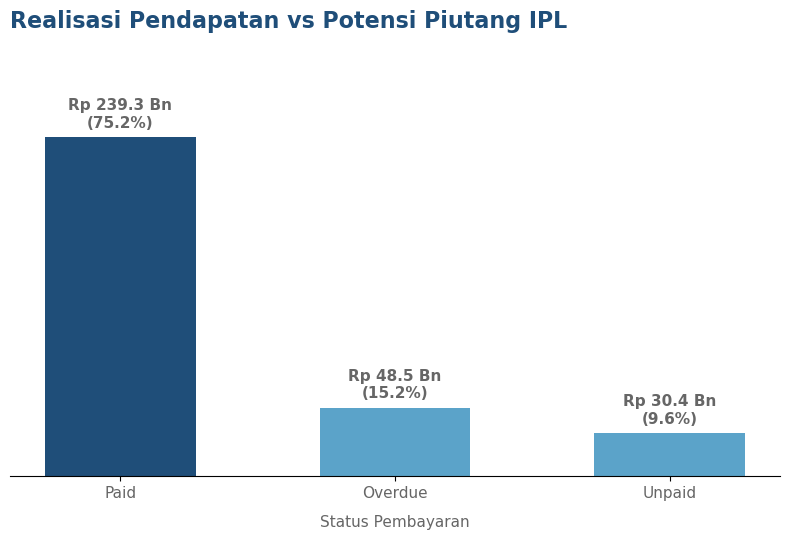

In [41]:


PRIMARY   = '#1F4E79'  
ACCENT    = '#5BA3C9'  
GRAY      = '#666666'  


plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = False


status_amount = (
    df_master
    .groupby("payment_status")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)


status_amount_in_billion = status_amount / 1e9

df_plot = pd.DataFrame({
    'Status': status_amount_in_billion.index,
    'Amount_Bn': status_amount_in_billion.values
})


fig, ax = plt.subplots(figsize=(8, 5.5))


colors = [PRIMARY if status == 'Paid' else ACCENT for status in df_plot['Status']]
bars = ax.bar(df_plot['Status'], df_plot['Amount_Bn'], color=colors, width=0.55)


total_all = df_plot['Amount_Bn'].sum()

for bar in bars:
    height = bar.get_height()
    percentage = (height / total_all) * 100
    
    # Menampilkan format: "Rp XXX.X Bn (XX.X%)"
    label_text = f'Rp {height:,.1f} Bn\n({percentage:.1f}%)'
    
    ax.text(
        bar.get_x() + bar.get_width()/2,  # Posisi tengah batang (X)
        height + (total_all * 0.015),    # Posisi sedikit di atas batang (Y)
        label_text,
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color=GRAY
    )


ax.set_title(
    "Realisasi Pendapatan vs Potensi Piutang IPL", 
    fontsize=16, 
    fontweight='bold', 
    pad=30, 
    color=PRIMARY,
    loc='left' 
)

ax.set_ylabel('Total Nilai (Rp Miliar)', fontsize=11, color=GRAY, labelpad=10)
ax.set_xlabel('Status Pembayaran', fontsize=11, color=GRAY, labelpad=10)
ax.tick_params(axis='both', which='major', labelsize=11, labelcolor=GRAY)


ax.set_ylim(0, df_plot['Amount_Bn'].max() * 1.2)


ax.get_yaxis().set_visible(False)

plt.tight_layout()


plt.savefig('revenue_by_payment_status_clean.png', dpi=300, bbox_inches='tight')
plt.show()


#### 💡 Insight

**📊 Observasi:**
- Pendapatan terbesar berasal dari invoice dengan status Paid.
Namun masih terdapat proporsi pendapatan yang cukup besar pada status Overdue, yang berarti masih ada nilai tagihan yang belum berhasil dikonversi menjadi kas.

**🔍 Interpretasi:**
- Secara bisnis, perusahaan telah mampu menghasilkan revenue yang baik, tetapi sebagian revenue masih tertahan dalam bentuk piutang (accounts receivable).
- Semakin besar outstanding payment, semakin besar pula tekanan terhadap cash flow, meskipun secara akuntansi revenue sudah tercatat.

**📌 Rekomendasi:**
- Prioritaskan collection terhadap pelanggan dengan nominal tunggakan terbesar (high-value accounts).
- Terapkan reminder otomatis sebelum jatuh tempo untuk mengurangi potensi keterlambatan pembayaran.
- Buat dashboard monitoring collection agar tim dapat memantau perkembangan outstanding secara berkala.

## **Chart 2 Outstanding amount > 6 months**

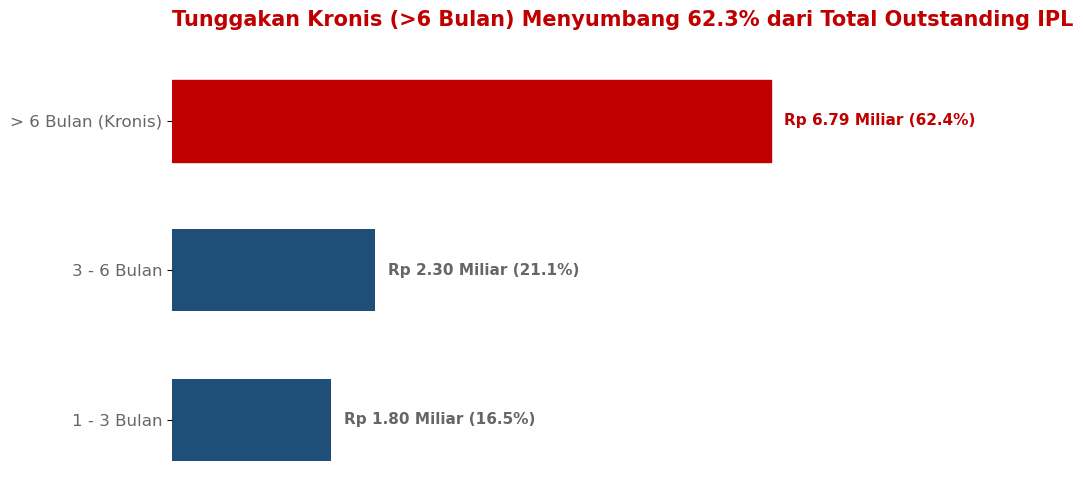

In [42]:


PRIMARY      = '#1F4E79'  
ALERT_COLOR  = '#C00000'  
GRAY         = '#666666'  
LIGHT_GRAY   = '#F5F5F5'  


plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False


aging_data = {
    'Durasi Tunggakan': ['1 - 3 Bulan', '3 - 6 Bulan', '> 6 Bulan (Kronis)'],
    'Nilai Outstanding (Miliar)': [1.8, 2.3, 6.79] 
}

df_aging = pd.DataFrame(aging_data)


fig, ax = plt.subplots(figsize=(10, 5))


bars = ax.barh(
    df_aging['Durasi Tunggakan'], 
    df_aging['Nilai Outstanding (Miliar)'], 
    color=PRIMARY, 
    height=0.55
)


bars[2].set_color(ALERT_COLOR)


total_outstanding = df_aging['Nilai Outstanding (Miliar)'].sum()

for bar in bars:
    width = bar.get_width()
    percentage = (width / total_outstanding) * 100
    
    label_text = f'Rp {width:,.2f} Miliar ({percentage:.1f}%)'
    
 
    text_color = ALERT_COLOR if width == 6.79 else GRAY
    
    ax.text(
        width + 0.15,                       
        bar.get_y() + bar.get_height()/2,   
        label_text, 
        va='center', 
        ha='left', 
        fontsize=11, 
        fontweight='bold', 
        color=text_color
    )


ax.set_title(
    'Tunggakan Kronis (>6 Bulan) Menyumbang 62.3% dari Total Outstanding IPL', 
    fontsize=15, 
    fontweight='bold', 
    pad=25, 
    color=ALERT_COLOR, 
    loc='left'
)


ax.set_xlabel('Nilai Outstanding (dalam Miliar Rupiah)', fontsize=11, color=GRAY, labelpad=10)
ax.set_xlim(0, 9.0) 
ax.get_xaxis().set_visible(False) 
ax.tick_params(axis='y', which='major', labelsize=12, labelcolor=GRAY)

plt.tight_layout()


plt.savefig('outstanding_aging_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Insight

**📊 Observasi:**
- Tunggakan Kronis lebih dari 6 bulan berturut-turut menyumbang 62,3% dari total outstanding IPL. 
- Nilai total outstanding terbesar jauh lebih tinggi dari 1-3 bulan maupun 3-6 bulan yaitu sebesar Rp 6,79 Milliar.

**🔍 Interpretasi:**
- Mayoritas piutang telah masuk dalam high-risk receivable.
- Semakin lama umur piutang maka akan makin kecil peluang pembayaran karena pemilik rumah cenderung semakin sulit untuk dihubungi atau kehilangan motivasi untuk memlunasi piutang yang ada.

**📌 Rekomendasi:**
- Pisahkan strategi collection berdasarkan umur piutang:
    * 1-3 bulan -> Reminder otomatis
    * 3-6 bulan -> Telepon dan negosiasi pembayaran
    * lebih dari 6 bulan -> Penanganan khusus melalui collection intensif atau legal recovery

## **Chart 3 Top Township Overdue Amount**

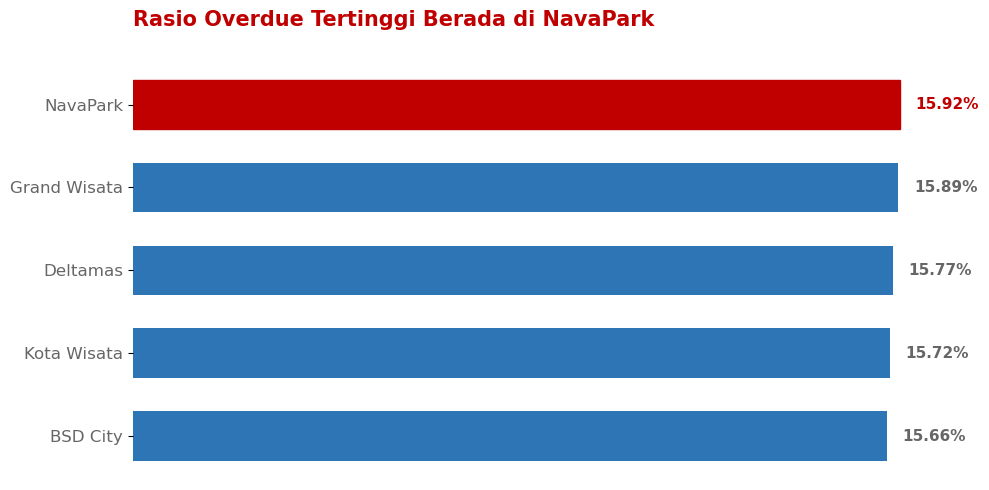

In [43]:
PRIMARY      = '#1F4E79'  
SECONDARY    = '#2E75B6'  
ALERT_COLOR  = '#C00000'  
GRAY         = '#666666'  


plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False


df_master["is_arrear"] = df_master["payment_status"].isin(["Overdue"])
township_overdue = df_master.groupby("township_name")["is_arrear"].mean().sort_values(ascending=True)

df_township_plot = pd.DataFrame({
    'Township': township_overdue.index,
    'Arrear_Rate': township_overdue.values
})


fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    df_township_plot['Township'], 
    df_township_plot['Arrear_Rate'], 
    color=SECONDARY, 
    height=0.6
)

bars[-1].set_color(ALERT_COLOR)


max_rate = df_township_plot['Arrear_Rate'].max()

for bar in bars:
    width = bar.get_width()
    
  
    label_text = f'{width:.2%}'
    
  
    text_color = ALERT_COLOR if width == max_rate else GRAY
    
    ax.text(
        width + (max_rate * 0.02),          
        bar.get_y() + bar.get_height()/2,   
        label_text, 
        va='center', 
        ha='left', 
        fontsize=11, 
        fontweight='bold', 
        color=text_color
    )

ax.set_title(
    f'Rasio Overdue Tertinggi Berada di {df_township_plot["Township"].iloc[-1]}', 
    fontsize=15, 
    fontweight='bold', 
    pad=25, 
    color=ALERT_COLOR,
    loc='left'
)


ax.get_xaxis().set_visible(False) #
ax.tick_params(axis='y', which='major', labelsize=12, labelcolor=GRAY)

plt.tight_layout()
plt.savefig('top_township_overdue_rate.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Insight

**📊 Observasi:**
- Rasio overdue antar township menunjukkan pola yang relatif konsisten tanpa ada perbedaan yang signifikan.

**🔍 Interpretasi:**
- Temuan ini menunjukkan bahwa resiko keterlambatan pembayaran terjadi secara menyeluruh dan tidak berpusat pada lokasi tertentu. Dengan demikian, faktor operasional atau perilaku pelanggan kemungkinan memiliki pengaruh yang lebih besar daripada faktor geografis.

**📌 Rekomendasi:**
- Fokuskan upaya peningkatan collection ke faktor yang lebih diskriminatif, seperti aging invoice, status hunian, atau kategori pelanggan, dibandingkan melakukan intervansi berdasarkan township.

## **Chart 4 Overdue Amount by Cluster Category**

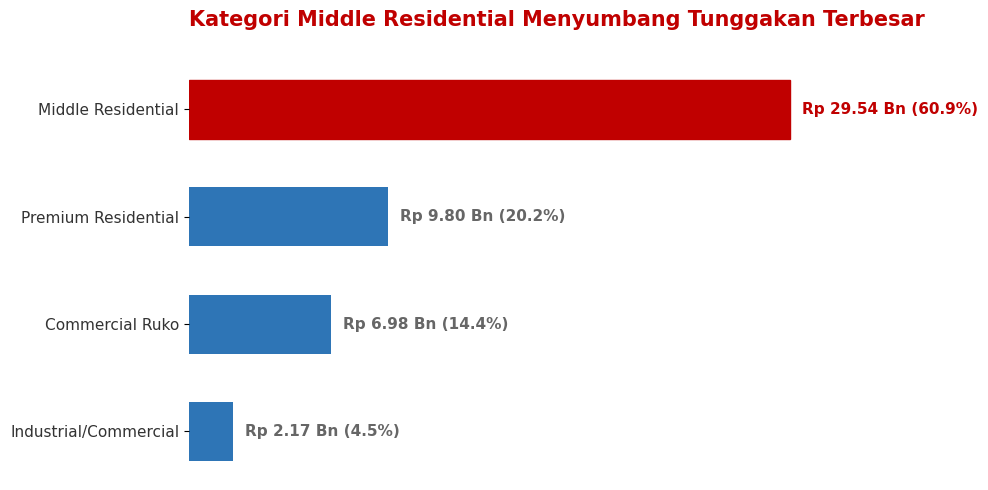

In [44]:
PRIMARY      = '#1F4E79'  
SECONDARY    = '#2E75B6'  
ALERT_COLOR  = '#C00000'  
GRAY         = '#666666'  


plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False


cluster_analysis = (
    df_master[df_master["payment_status"] == "Overdue"]
    .groupby("cluster_category")["total_amount"]
    .sum()
    .sort_values(ascending=True) 
)

cluster_in_billion = cluster_analysis / 1e9

df_cluster_plot = pd.DataFrame({
    'Cluster_Category': cluster_in_billion.index,
    'Amount_Bn': cluster_in_billion.values
})


fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    df_cluster_plot['Cluster_Category'], 
    df_cluster_plot['Amount_Bn'], 
    color=SECONDARY, 
    height=0.55
)


bars[-1].set_color(ALERT_COLOR)


total_overdue = df_cluster_plot['Amount_Bn'].sum()
max_value = df_cluster_plot['Amount_Bn'].max()

for bar in bars:
    width = bar.get_width()
    percentage = (width / total_overdue) * 100
    

    label_text = f'Rp {width:,.2f} Bn ({percentage:.1f}%)'
    
   
    text_color = ALERT_COLOR if width == max_value else GRAY
    
    ax.text(
        width + (max_value * 0.02),          
        bar.get_y() + bar.get_height()/2,   
        label_text, 
        va='center', 
        ha='left', 
        fontsize=11, 
        fontweight='bold', 
        color=text_color
    )

ax.set_title(
    f"Kategori {df_cluster_plot['Cluster_Category'].iloc[-1]} Menyumbang Tunggakan Terbesar", 
    fontsize=15, 
    fontweight='bold', 
    pad=25, 
    color=ALERT_COLOR,
    loc='left' 
)


ax.get_xaxis().set_visible(False) 
ax.tick_params(axis='y', which='major', labelsize=11, labelcolor='#333333')

ax.set_xlim(0, max_value * 1.3)

plt.tight_layout()


plt.savefig('overdue_by_cluster_category.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Insight

**📊 Observasi:**
- Sebagian besar nilai tunggakan berasal dari satu kategori cluster yaitu Middle Residential sebesar 60.9%.
- Kontribusi nilai nya jauh lebih besar dibandingkan cluster lainnya.

**🔍 Interpretasi:**
- Resiko piutang perusahaan tidak tersebar merata, tetapi terkonsentrasi pada segmen pelanggan tertentu.
- Hal ini menunjukkan bahwa peluang terbuka untuk melakukan strategi collection yang lebih terarah dan spesifik daripada melakukan pendekatan yang sama pada seluruh pelanggan.

**📌 Rekomendasi:**
- Fokuskan program colection pada kategori Middle Residential.
- Analysis karakteristik pelanggan atau pemilik pada kategori Middle Residential untuk mengetahui faktor apa saja yang menyebabkan tingginya tunggakan
- Pertimbangkan kebijakan pembayaran yang lebih fleksibel apabila ditemukan faktor ekonomi sebagai penyeba utama.

## **Chart 5 Majority Overdue IPL from Vacant**

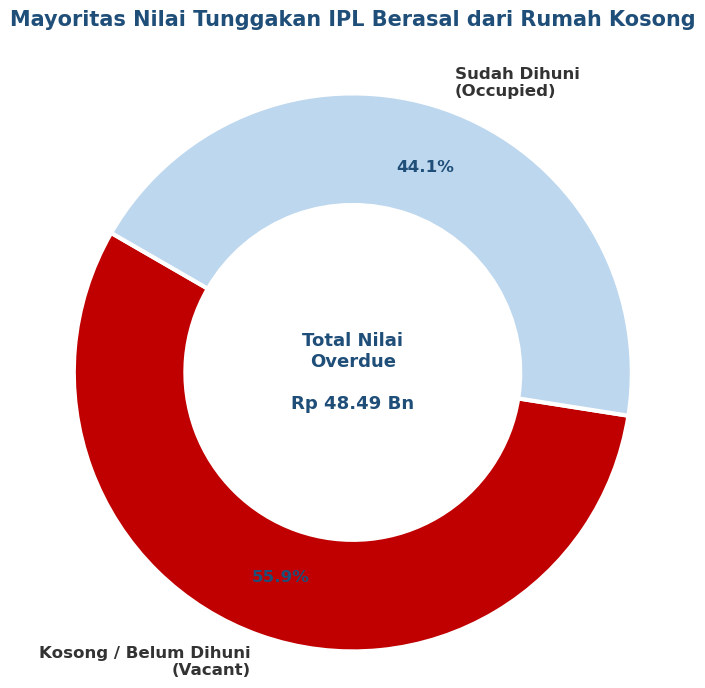

In [45]:
ALERT_COLOR  = '#C00000'  
SAFE_COLOR   = '#BDD7EE'  
PRIMARY      = '#1F4E79'  
GRAY         = '#666666'  

plt.rcParams['font.family'] = 'DejaVu Sans'


df_overdue = df_master[df_master["payment_status"] == "Overdue"]

vacant_tunggakan = df_overdue.groupby("is_vacant")["total_amount"].sum()


sizes = [vacant_tunggakan.get(True, 0), vacant_tunggakan.get(False, 0)]
labels = ['Kosong / Belum Dihuni\n(Vacant)', 'Sudah Dihuni\n(Occupied)'] 
colors = [ALERT_COLOR, SAFE_COLOR]

grand_total_overdue = sum(sizes)


fig, ax = plt.subplots(figsize=(7, 7))


wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=150,
    colors=colors,
    textprops=dict(color=GRAY, fontsize=11),
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=3), 
    pctdistance=0.78 
)

for autotext in autotexts:
    
    if '62.' in autotext.get_text() or '7' in autotext.get_text(): 
        autotext.set_color('white') 
    else:
        autotext.set_color(PRIMARY) 
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')


for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('semibold')
    text.set_color('#333333')


ax.text(
    0, 0, 
    f'Total Nilai\nOverdue\n\nRp {grand_total_overdue/1e9:.2f} Bn', 
    ha='center', va='center', 
    fontsize=13, fontweight='bold', color=PRIMARY
)


ax.set_title(
    "Mayoritas Nilai Tunggakan IPL Berasal dari Rumah Kosong", 
    fontsize=15, 
    fontweight='bold', 
    pad=30, 
    color=PRIMARY, 
    loc='center'
)

ax.axis('equal')  
plt.tight_layout()


plt.savefig('tunggakan_persentase_vacant_clean.png', dpi=300, bbox_inches='tight')
plt.show()

## **Chart 6 Missing Contact Number**

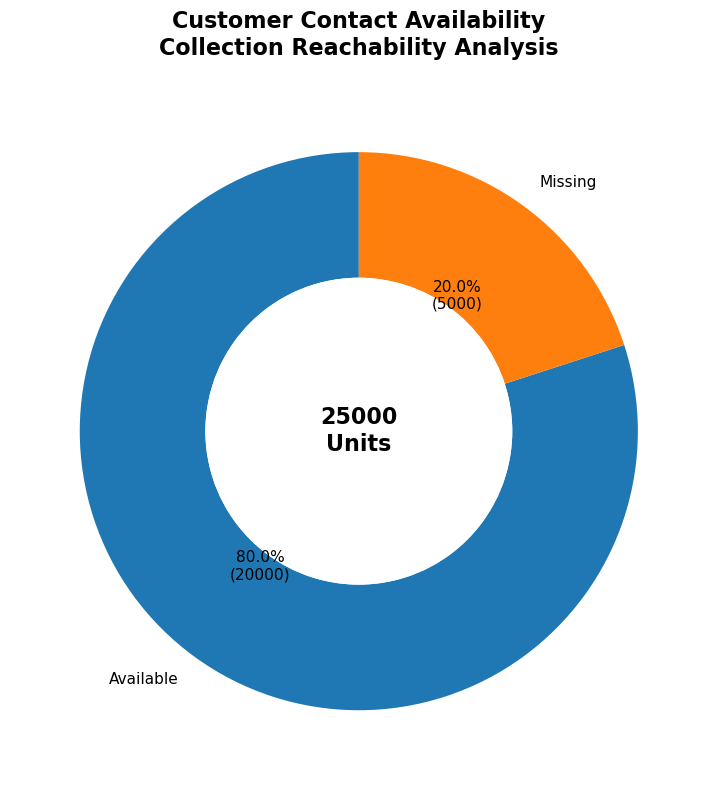

In [46]:

contact = pd.Series({
    "Available": df_units["contact_number"].notna().sum(),
    "Missing": df_units["contact_number"].isna().sum()
})


fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    contact.values,
    labels=contact.index,
    autopct=lambda pct: f'{pct:}%\n({int(round(pct/100*contact.sum()))})',
    startangle=90,
    wedgeprops=dict(width=0.45),  
    textprops={'fontsize': 11}
)

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
fig.gca().add_artist(centre_circle)

ax.text(
    0, 0,
    f'{contact.sum()}\nUnits',
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold'
)

plt.title(
    "Customer Contact Availability\nCollection Reachability Analysis",
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

#### 💡 Insight

**📊 Observasi:**
- Terdapat 20% unit atau sebanyak 5000 unit yang tidak memiliki nomor telepon pemilik yang valid.

**🔍 Interpretasi:**
- Unit yang tidak memiliki kontak pemilik yang valid akan menurunkan efetivitas aktivitas collection.
- Pemilik dengan nomor yang tidak valid atau tidak ada berpotensi menjadi kelompok yang berisiko tinggi mengalami keterlambatan pembayarn karena sulit untuk dihubungi.

**📌 Rekomendasi:**
- Jadikan kontak pelanggan sebagai KPI administrasi pelanggan.
- Lakukan validasi dan pembaharuan data secara berkala.
- Wajibkan verifikasi nomor telepon pelanggan saat melakukan transaksi pelayanan pelanggan.


## **Chart 7 ERP Logic Error**

C:\Users\nadya\AppData\Local\Temp\ipykernel_20308\2362738581.py:81: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nadya\AppData\Local\Temp\ipykernel_20308\2362738581.py:82: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig('erp_logic_error_clean.png', dpi=300, bbox_inches='tight')
c:\Users\nadya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


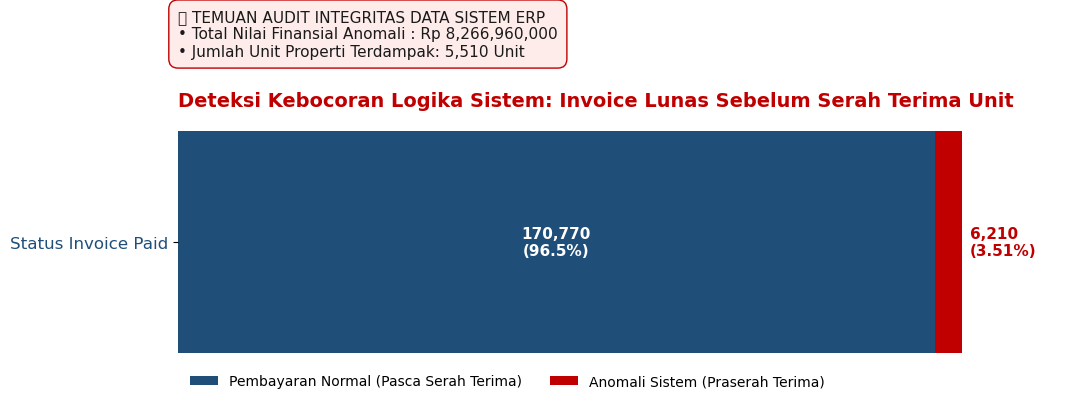

In [47]:
PRIMARY      = '#1F4E79'  
ALERT_COLOR  = '#C00000'  
GRAY         = '#666666'  


plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False


df_ipl_clean["payment_date"] = pd.to_datetime(df_ipl_clean["payment_date"])
df_units["handover_date"] = pd.to_datetime(df_units["handover_date"])

df_ipl_clean = df_ipl_clean.drop(columns=["handover_date"], errors="ignore")
df_ipl_clean = df_ipl_clean.merge(df_units[["unit_id", "handover_date"]], on="unit_id", how="left")

df_ipl_clean["is_logical_error"] = (
    (df_ipl_clean["payment_status"] == "Paid") &
    (df_ipl_clean["payment_date"] < df_ipl_clean["handover_date"])
)

n_error = df_ipl_clean["is_logical_error"].sum()
n_paid = (df_ipl_clean["payment_status"] == "Paid").sum()
n_normal = n_paid - n_error
error_rate = n_error / n_paid

error_value = df_ipl_clean.loc[df_ipl_clean["is_logical_error"], "total_amount"].sum()
n_units_affected = df_ipl_clean.loc[df_ipl_clean["is_logical_error"], "unit_id"].nunique()


fig, ax = plt.subplots(figsize=(11, 5))


bar_normal = ax.barh(['Status Invoice Paid'], [n_normal], color=PRIMARY, height=0.4, label='Pembayaran Normal (Pasca Serah Terima)')

bar_error = ax.barh(['Status Invoice Paid'], [n_error], left=[n_normal], color=ALERT_COLOR, height=0.4, label='Anomali Sistem (Praserah Terima)')


ax.text(
    n_normal / 2, 0, 
    f'{n_normal:,}\n({(n_normal/n_paid):.1%})', 
    va='center', ha='center', fontsize=11, fontweight='bold', color='white'
)

ax.text(
    n_paid + (n_paid * 0.01), 0, 
    f'{n_error:,}\n({error_rate:.2%})', 
    va='center', ha='left', fontsize=11, fontweight='bold', color=ALERT_COLOR
)


info_box_text = (
    f"🚨 TEMUAN AUDIT INTEGRITAS DATA SISTEM ERP\n"
    f"• Total Nilai Finansial Anomali : Rp {error_value:,.0f}\n"
    f"• Jumlah Unit Properti Terdampak: {n_units_affected:,} Unit"
)

ax.text(
    0, 0.42, info_box_text, 
    fontsize=11, color='#1A1A1A', weight='medium',
    va='top', ha='left',
    bbox=dict(boxstyle="round,pad=0.6", facecolor='#FEECEB', edgecolor=ALERT_COLOR, linewidth=1)
)


ax.set_title(
    "Deteksi Kebocoran Logika Sistem: Invoice Lunas Sebelum Serah Terima Unit", 
    fontsize=14, fontweight='bold', pad= 10, color=ALERT_COLOR, loc='left'
)

ax.get_xaxis().set_visible(False)
ax.tick_params(axis='y', which='major', labelsize=12, labelcolor=PRIMARY)

ax.set_xlim(0, n_paid * 1.15)


ax.legend(loc='lower left', bbox_to_anchor=(0, -0.15), ncol=2, frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('erp_logic_error_clean.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Insight

**📊 Observasi:**
- Ditemukan transaksi berstatus "Paid" yang terjadi, tetapi tanggal pembayarannya lebih awal daripada tanggal serah terima unit.

**🔍 Interpretasi:**
- Kondisi ini tidak mungkin secara logika bisnis dan mengindikasikan adanya masalah kualitas data, kesalah input atau sinkronisasi antar sistem.

**📌 Rekomendasi:**
- Terapkan validasi otomatis pada sistem agar payment date tidak boleh lebih awal dari handover date.
- Audit seluruh transaksi yang teriidentifikasi.
- Bangun data quality monitoring sebagai bagian dari proses ETL

## **Chart 8 Water Usage Outlier** 

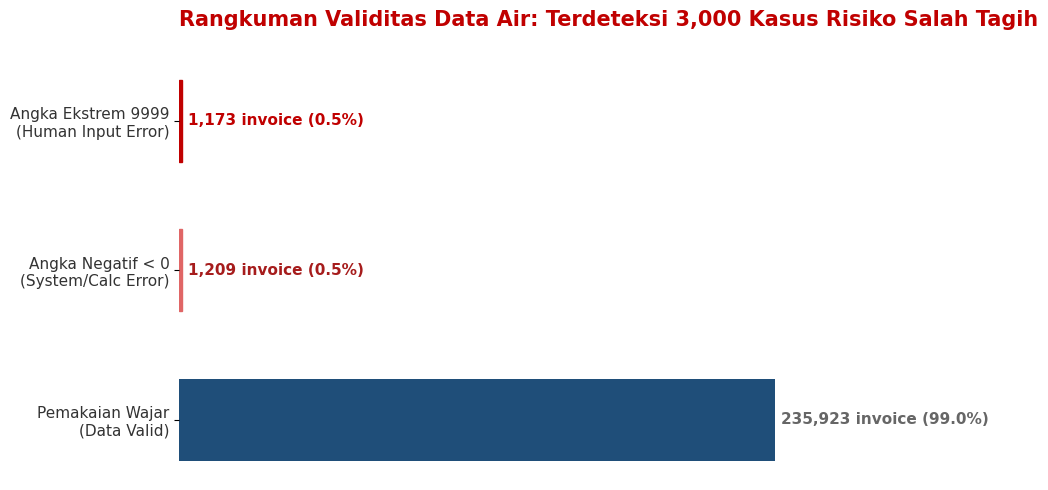

In [48]:
PRIMARY      = '#1F4E79'  
ALERT_COLOR  = '#C00000'  
ACCENT_RED   = '#E06666' 
GRAY         = '#666666'  

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False


n_negative = (df_ipl_clean['water_usage_m3'] < 0).sum()
n_extreme = (df_ipl_clean['water_usage_m3'] >= 9000).sum()
n_normal = len(df_ipl_clean) - (n_negative + n_extreme)
total_records = len(df_ipl_clean)


df_water_summary = pd.DataFrame({
    'Kategori Pencatatan': [
        'Pemakaian Wajar\n(Data Valid)', 
        'Angka Negatif < 0\n(System/Calc Error)', 
        'Angka Ekstrem 9999\n(Human Input Error)'
    ],
    'Jumlah Baris Data': [n_normal, n_negative, n_extreme]
})


fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    df_water_summary['Kategori Pencatatan'], 
    df_water_summary['Jumlah Baris Data'], 
    color=PRIMARY, 
    height=0.55
)

bars[1].set_color(ACCENT_RED)   
bars[2].set_color(ALERT_COLOR) 


for bar in bars:
    width = bar.get_width()
    percentage = (width / total_records) * 100

    label_text = f'{width:,} invoice ({percentage:.1f}%)'
    
    if width == n_normal:
        text_color = GRAY
    elif width == n_extreme:
        text_color = ALERT_COLOR
    else:
        text_color = '#A61C1C'
        
    ax.text(
        width + (total_records * 0.01),     
        bar.get_y() + bar.get_height()/2,   
        label_text, 
        va='center', 
        ha='left', 
        fontsize=11, 
        fontweight='bold', 
        color=text_color
    )

ax.set_title(
    "Rangkuman Validitas Data Air: Terdeteksi 3,000 Kasus Risiko Salah Tagih", 
    fontsize=15, 
    fontweight='bold', 
    pad=25, 
    color=ALERT_COLOR, 
    loc='left'
)

ax.get_xaxis().set_visible(False)
ax.tick_params(axis='y', which='major', labelsize=11, labelcolor='#333333')

ax.set_xlim(0, total_records * 1.2)

plt.tight_layout()
plt.savefig('alternatif_water_outliers_clean.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Insight

**📊 Observasi:**
- Ditemukan pemakaian air negatif dan ekstrem (9999) yang tidak wajar dan realistis.

**🔍 Interpretasi:**
- Temuan ini kemungkinan berasal dari kesalahan input atau error sistem.
- Jika digunakan dalam proses billing, kondisi ini berpotensi menghasilkan tagihan yang tidak akurat.

**📌 Rekomendasi:**
- Terapkan validasi pada sistem pencatatan meter air.
- Gunakan batas maksimum dan minimum yang realistis.
- Tandai data anomali untuk dilakukan verifikasi sebelum invoice ditentukan

## **Chart 9 Top Payment method**

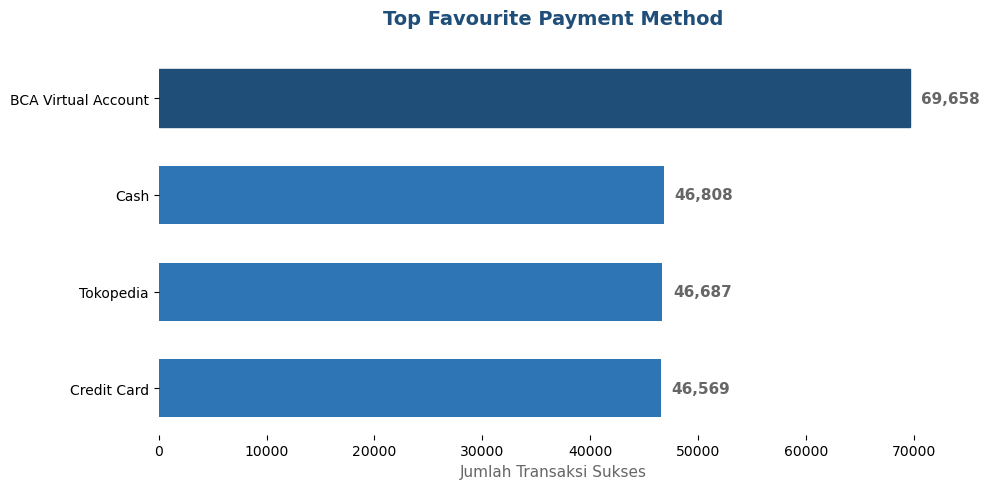

In [49]:
PRIMARY   = '#1F4E79'
SECONDARY = '#2E75B6'
ACCENT    = '#5BA3C9'
LIGHT     = '#BDD7EE'
GRAY      = '#666666'

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


payment_methods = ['BCA Virtual Account', 'Cash', 'Tokopedia', 'Credit Card']
transaction_counts = [69658, 46808, 46687, 46569]

df_pay = pd.DataFrame({'Metode': payment_methods, 'Total Transaksi': transaction_counts})
df_pay = df_pay.sort_values(by='Total Transaksi', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_pay['Metode'], df_pay['Total Transaksi'], color=SECONDARY, height=0.6)


bars[-1].set_color(PRIMARY)


for bar in bars:
    width = bar.get_width()
    ax.text(width + 1000, bar.get_y() + bar.get_height()/2, f'{width:,}', 
            va='center', ha='left', fontsize=11, fontweight='bold', color=GRAY)

ax.set_title('Top Favourite Payment Method', 
             fontsize=14, fontweight='bold', pad=20, color=PRIMARY)
ax.set_xlabel('Jumlah Transaksi Sukses', fontsize=11, color=GRAY)
plt.tight_layout()
plt.savefig('payment_method_distribution.png', dpi=300)
plt.show()

#### 💡 Insight

**📊 Observasi:**
- BCA Virtual Account merupakan metode pembayaran yang paling banyak digunakan oleh pelanggan.
- Metode lainnya seperti cash, tokopedia dan credit card relatif seimbang tetapi lebih rendah.

**🔍 Interpretasi:**
- Temuan ini menunjukkan bahwa pelanggan menyukai metode pembayaran yang cepat, mudah dan otomatis.
- Hal ini menunjukkan adanya preferensi pada kanal pembayaran digital.

**📌 Rekomendasi:**
- Optimalkan kanal virtual account sebagai metode pembayaran utama.
- Berikan Insentif atau promo bagi pelanggan yang melakukan pembayaran digital.
- Evaluasi efektivitas kanal dengan pembayaran transaksi rendah untuk menentukan apakah masih layak dipertahankan atau perlu ditingkatkan
